In [4]:
pip install opencv-python numpy matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [8]:
img = cv2.imread("input.jpg")

if img is None:
    raise RuntimeError("input.jpg not found. Please place the image in the same folder.")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [14]:
mask = np.zeros(img.shape[:2], np.uint8)

bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

h, w = img.shape[:2]
rect = (int(w * 0.15), int(h * 0.05), int(w * 0.7), int(h * 0.9))

cv2.grabCut(img, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

seg_mask = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")

In [15]:
hair_region = np.zeros_like(seg_mask)
hair_region[:int(h * 0.45), :] = 1  # top 45%

hair_mask = seg_mask * hair_region


In [16]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, dark_mask = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)
dark_mask = dark_mask // 255

hair_mask_refined = hair_mask * dark_mask

In [18]:
output = img.copy()

hair_color = np.zeros_like(img)
hair_color[:] = (60, 40, 20)  # brown tone (BGR)

alpha = 0.6

for c in range(3):
    output[:, :, c] = np.where(
        hair_mask_refined == 1,
        output[:, :, c] * (1 - alpha) + hair_color[:, :, c] * alpha,
        output[:, :, c]
    )

In [19]:
cv2.imwrite("output.jpg", output)

True

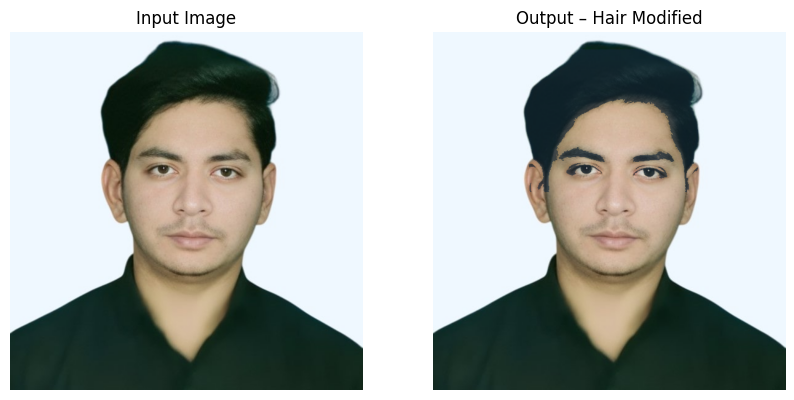

Output saved as output.jpg


In [23]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Output – Hair Modified")
plt.axis("off")

plt.show()

print("Output saved as output.jpg")

In [21]:
hair_colors = {
    "brown": (60, 40, 20),
    "black": (20, 20, 20),
    "red": (40, 40, 160),
    "green": (40, 120, 40),
    "blue": (160, 40, 40)
}

alpha = 0.6

outputs = {}

for color_name, color_bgr in hair_colors.items():
    temp = img.copy()
    hair_color = np.zeros_like(img)
    hair_color[:] = color_bgr

    for c in range(3):
        temp[:, :, c] = np.where(
            hair_mask_refined == 1,
            temp[:, :, c] * (1 - alpha) + hair_color[:, :, c] * alpha,
            temp[:, :, c]
        )

    outputs[color_name] = temp
    cv2.imwrite(f"output_{color_name}.jpg", temp)


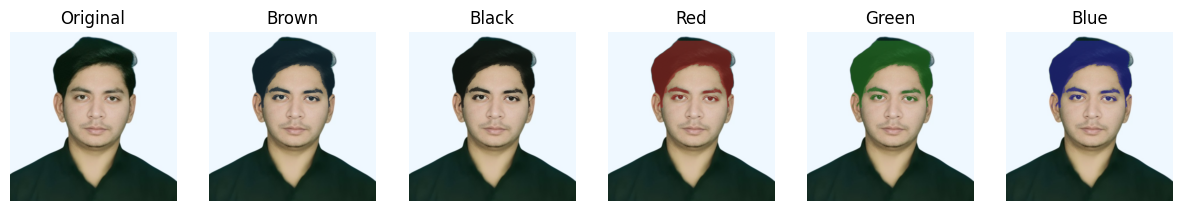

In [22]:
plt.figure(figsize=(15, 6))

plt.subplot(1, len(outputs) + 1, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

for i, (name, image) in enumerate(outputs.items(), start=2):
    plt.subplot(1, len(outputs) + 1, i)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(name.capitalize())
    plt.axis("off")

plt.show()
